In [10]:
# S.T.E.P. 1: Загружаем датасет DS_Wine и смотрим на него

# Импортируем нужные библиотеки
from sklearn.datasets import load_wine
import pandas as pd
import numpy as np

Всего сортов три:
>#DEEP:
- **Класс 0** – первая провинция  
- **Класс 1** – вторая провинция  
- **Класс 2** – третья провинция  

Для каждого образца вина (всего их **178**) ты сделал 13 химических измерений (признаков). Вот они, как в реальном протоколе:

| № признака | Название (и что это значит "на пальцах")                                 |     |
| ---------- | ------------------------------------------------------------------------ | --- |
| 1          | Алкоголь – сколько градусов                                              |     |
| 2          | Яблочная кислота – одна из кислот, влияет на вкус                        |     |
| 3          | Зола – минеральный остаток после сжигания                                |     |
| 4          | Щёлочность золы – насколько щелочная зола                                |     |
| 5          | Магний – содержание магния                                               |     |
| 6          | Общий фенолы – антиоксиданты, влияют на цвет и вкус                      |     |
| 7          | Флавоноиды – подкласс фенолов (более полезные)                           |     |
| 8          | Нефлавоноидные фенолы – остальные фенолы                                 |     |
| 9          | Проантоцианины – вещества, дающие терпкость                              |     |
| 10         | Интенсивность цвета                                                      |     |
| 11         | Оттенок цвета                                                            |     |
| 12         | OD280/OD315 – отношение оптических плотностей (связано с возрастом вина) |     |
| 13         | Пролин – аминокислота                                                    |     |

Все эти числа – **вещественные** (с плавающей точкой), разные по масштабу. Например, алкоголь от 11% до 15%, а магний – от 70 до 160.

**Ключевая идея:** Вина одного сорта будут **похожи** по этим признакам (расстояние между ними маленькое), а разных сортов – разные.

In [11]:
DS_Wine = load_wine()
# 2. Смотрим, что внутри: описание, признаки, классы
print("=== Описание датасета ===\n")
print(DS_Wine.DESCR)  # выведет подробное описание на английском

print("\n=== Признаки (feature names) ===")
print(DS_Wine.feature_names) # это атрибуты-столбцы - из таблицы выше

print("\n=== Целевые классы (target names) ===")
print(DS_Wine.target_names)   # ['class_0', 'class_1', 'class_2'] – но мы знаем, что это сорта

# 3. Преобразуем в удобную таблицу pandas DataFrame
df = pd.DataFrame(DS_Wine.data, columns=DS_Wine.feature_names)
df['target'] = DS_Wine.target  # добавляем столбец с классом

print("\n=== Первые 5 строк данных ===")
print(df.head())

# 4. Базовая информация: размер, пропуски, типы данных
print("\n=== Информация о датафрейме ===")
print(df.info())

# 5. Описательная статистика по признакам (среднее, мин, макс и т.д.)
print("\n=== Описательная статистика ===")
print(df.describe())

# 6. Проверка баланса классов: сколько образцов в каждом классе
print("\n=== Распределение классов ===")
print(df['target'].value_counts())

=== Описание датасета ===

.. _wine_dataset:

Wine recognition dataset
------------------------

**Data Set Characteristics:**

:Number of Instances: 178
:Number of Attributes: 13 numeric, predictive attributes and the class
:Attribute Information:
    - Alcohol
    - Malic acid
    - Ash
    - Alcalinity of ash
    - Magnesium
    - Total phenols
    - Flavanoids
    - Nonflavanoid phenols
    - Proanthocyanins
    - Color intensity
    - Hue
    - OD280/OD315 of diluted wines
    - Proline
    - class:
        - class_0
        - class_1
        - class_2

:Summary Statistics:

============================= ==== ===== ======= =====
                                Min   Max   Mean     SD
============================= ==== ===== ======= =====
Alcohol:                      11.0  14.8    13.0   0.8
Malic Acid:                   0.74  5.80    2.34  1.12
Ash:                          1.36  3.23    2.36  0.27
Alcalinity of Ash:            10.6  30.0    19.5   3.3
Magnesium:                 

- `wine.DESCR` – полное описание датасета (на английском, но можно перевести)
    
- `df.head()` – табличку с первыми 5 винами, их 13 признаками и классом
    
- `df.info()` – покажет, что нет пропусков, 178 строк, все типы float64, кроме класса (int)
    
- `df.describe()` – средние, стандартные отклонения, минимумы-максимумы. Обрати внимание: масштабы признаков разные (например, алкоголь ~13, магний ~100). Это важно для метрических методов – потом будем **нормализовывать**.
    
- `value_counts()` – убедимся, что классы примерно равны (около 60 образцов на класс).

>#MAKEME: **разделить данные на train и test**
# Task 1: <u>Hold-out</u> на train/test данные

In [12]:
# Task 1: Hold-out разбиение Wine на train/test

from sklearn.model_selection import train_test_split

#ARCHV: Выше уже есть
#  # Загружаем датасет (если ещё не загружен)
# from sklearn.datasets import load_wine
# DS_Wine = load_wine()

# Превращаем признаки в DataFrame для удобства (можно и без этого)
X = pd.DataFrame(DS_Wine.data, columns=DS_Wine.feature_names)
y = DS_Wine.target # выходы - те целевые значения/функции, что должны будут закономерно получатся у нашей ML-системы

# #NOTE: X — это таблица с 13 столбцами-признаками, y — массив с числами 0,1,2 (классы)

# Разбиваем. random_state — фиксируем для воспроизводимости (каждый раз одинаковое разбиение)
# test_size=0.30 означает 30% данных уходят в test (54 образца из 178)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y  
)

# #NOTE: stratify=y — это умный параметр. Он делает так, что в train и test 
# распределение классов будет таким же, как в исходном наборе.
# Без stratify могло бы случиться, например, что в test попадут все образцы класса 2 — тогда оценка будет нечестной.

>#NOTE:
## 1. Ключевая идея — «экзамен без шпаргалки»

Весь смысл разбиения `train/test` — **имитировать реальный мир**:

- В `train` мы даём модели **правильные ответы** вместе с признаками (обучение).
- В `test` мы **забираем правильные ответы** и просим модель предсказать их **самостоятельно**.

То есть модель видит только признаки `X_test`, а `y_test` мы используем **только для подсчёта ошибок**, не показывая их модели. Это честный экзамен.

---

## 2. `X` и `y` — что это в голове?

Представь **таблицу Excel**:

| alcohol | malic_acid | ... | proline | target (сорт) |
|---------|------------|-----|---------|---------------|
| 13.2    | 1.78       | ... | 560     | 0             |
| 12.4    | 2.45       | ... | 510     | 1             |
| ...     | ...        | ... | ...     | ...           |

- Вся таблица — это исходный датасет.
- **X** (признаки) — все столбцы, кроме последнего. Это 13 чисел для каждого вина.
- **y** (целевая переменная) — последний столбец «target», который мы хотим **научиться предсказывать**.

В коде мы разделяем их на две независимые переменные `X` и `y` для удобства.

---

## 3. Параметр `test_size=0.30` — почему именно 0.30?

Это доля данных, которая уходит на экзамен (test). Оставшиеся 70% идут на обучение.

Число 0.30 не высечено в камне. В академической среде чаще берут 0.20 или 0.30.  
**Логика выбора:**

| test_size | Плюсы | Минусы |
|-----------|-------|--------|
| 0.20 (20%) | Больше данных на обучение (особенно полезно, если данных мало) | Меньше тестовых примеров → оценка точности может быть нестабильной |
| 0.30 (30%) | **Компромисс** — достаточно тестовых данных для надёжной оценки | Немного меньше данных на обучение |
| 0.40 (40%) | Много тестов → стабильная оценка | Обучающая выборка сильно урезана → модель может хуже обучиться |

**Почему в ТЗ не указано?** Потому что это не принципиально для демонстрации методов. Главное — **сравнить hold-out и кросс-валидацию**. Можно взять 0.30 или 0.20 — выводы о том, какое K лучше, останутся примерно теми же.

После выполнения всей работы можно поменять `test_size` и увидеть, как изменятся графики. Это полезный эксперимент.

---

## 4. `random_state=42` — зачем фиксировать?

Без `random_state` каждое новое выполнение кода даст **разный** набор вин в train и test. Это хорошо для исследования (проверить устойчивость), но плохо для **воспроизводимости**:

- Ты получила accuracy 94% при K=5. Через неделю запустила код — accuracy 91%, и ты не понимаешь почему. Дело в том, что разбиение изменилось.
- Преподаватель попросил показать код. Он запускает его у себя — получает другие цифры, потому что random_state не зафиксирован.

Число 42 — традиция из книги «Автостопом по галактике» (Ответ на главный вопрос жизни, вселенной и всего такого). Можно использовать любое число: `random_state=1`, `random_state=2024`, `random_state=123`.

---

## 5. `stratify=y` — почему это «умно»?

Смотри, в исходном датасете Wine распределение классов **неравномерное** (59, 71, 48). Без `stratify` может случиться случайный перекос:

- В `train` попадут все образцы класса 2, а в `test` — ни одного. Тогда модель не сможет научиться различать класс 2 (редкий), а на экзамене вопросов по нему не будет — оценка будет завышена.
- Или наоборот: в `test` попадут непропорционально много образцов класса 2, который модель плохо различает, — оценка будет занижена.

**Что делает `stratify=y`:**  
Он заставляет sklearn сохранить в `train` и `test` **те же проценты классов**, что и в исходном наборе.

Пример (упрощённо):
- Исходный набор: 33% класса 0, 40% класса 1, 27% класса 2.
- `stratify=y` сделает так, что и в train, и в test будет примерно 33% / 40% / 27%.

**Это важно для ТЗ?** Да. Потому что мы будем сравнивать разные способы оценки (hold-out vs кросс-валидация). Чтобы сравнение было честным, тестовая выборка должна быть репрезентативной.

---

## 6. Иллюстрация на пальцах (маленький пример)

Представь, что у тебя всего **10 вин**, с распределением классов:  
класс 0 — 3 вина, класс 1 — 4 вина, класс 2 — 3 вина.

Мы хотим `test_size=0.30` (т.е. 3 вина уходят в test).

**Без `stratify`:**  
Может выпасть: в test попали 2 вина класса 1 и 1 вино класса 2, а класс 0 вообще не попал. Тогда обучаться модель будет без класса 0, и на экзамене вопросов по классу 0 не будет — точность может быть неправильной.

**С `stratify`:**  
Sklearn постарается сохранить пропорции: в test попадёт примерно 1 вино класса 0 (30% от 3 ≈ 1), 1 вино класса 1 (30% от 4 ≈ 1), 1 вино класса 2 (30% от 3 ≈ 1). Идеально.

---

## 7. Что теперь делать?

Запустить код и **посмотреть на вывод** `value_counts()` для `y_train` и `y_test`.  

Ты увидишь, что пропорции классов в train и test **очень близки** к исходным (59/178 ≈ 33%, 71/178 ≈ 40%, 48/178 ≈ 27%). Это результат работы `stratify`.

Если хочешь убедиться, убери `stratify=y` и запусти код ещё раз — распределение изменится (может стать чуть более неравномерным).


>[!warning] Теория по random
>
> KEEP: Приостановлена в файле [DEEP - Алгоритм псевдослучайных чисел]

# Task 2: Подбор самого оптимального <u>K</u>

In [13]:
# Task 2: Подбор оптимального K для kNN на hold-out (Wine)
# Предполагается, что X_train, X_test, y_train, y_test уже есть из Task 1

import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [14]:
# #CHILLOUT: будем перебирать K от 1 до 15 (для Wine этого достаточно)
k_range = range(1, 16)  # K = 1, 2, ..., 15
train_accuracies = []
test_accuracies = []
# print(k_range)

print("K | Train accuracy | Test accuracy")
print("--|---------------|--------------")

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)   # учимся на train
    y_train_pred = knn.predict(X_train)
    y_test_pred = knn.predict(X_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    print(f"{k:2d} | {train_acc:.3f}        | {test_acc:.3f}")
    
# Находим лучшее K по максимальной точности на test
#NOTE: Индекс макс значения в `test_accuracies` == индекс оптимального k в k_range
best_k = k_range[np.argmax(test_accuracies)] #WARN: np.argmax() - возвр индекс макс значения в массиве `test_accuracies`
best_acc = max(test_accuracies)
print(f"\n🏆 Оптимальное K = {best_k} с accuracy на test = {best_acc:.3f} ({best_acc*100:.1f}%)")


K | Train accuracy | Test accuracy
--|---------------|--------------
 1 | 1.000        | 0.704
 2 | 0.847        | 0.667
 3 | 0.855        | 0.685
 4 | 0.823        | 0.648
 5 | 0.806        | 0.722
 6 | 0.790        | 0.685
 7 | 0.774        | 0.741
 8 | 0.774        | 0.722
 9 | 0.774        | 0.722
10 | 0.742        | 0.741
11 | 0.734        | 0.722
12 | 0.726        | 0.704
13 | 0.734        | 0.722
14 | 0.702        | 0.704
15 | 0.734        | 0.722

🏆 Оптимальное K = 7 с accuracy на test = 0.741 (74.1%)


## #CHILLOUT — Почему мы перебираем K именно от 1 до 15?

Отличный вопрос. «Почему не от 1 до 100?» или «Почему не от 1 до 50?» — давай разберём.

---

### 1. А что такое K вообще?

K — это **количество соседей**, которых мы опрашиваем, чтобы принять решение.  
Если K слишком маленькое (1 или 2) — модель «нервная», может принять шум за сигнал.  
Если K слишком большое (например, 100) — модель становится слишком грубой, сглаживает всё подряд и перестаёт различать классы.

---

### 2. Почему именно до 15?

У нас **обучающая выборка** состоит из 124 образцов (вин).  
Максимальное разумное K — это **не больше трети обучающей выборки**, а лучше **гораздо меньше**, иначе модель просто всегда будет предсказывать самый частый класс среди всех 124 вин (это будет недообучение).

**Конкретно для Wine:**

- Если взять K = 124 (все обучающие вина) — модель всегда будет предсказывать класс, который чаще всего встречается в обучающей выборке (скорее всего класс 1, его 71 вино из 124). Это бессмысленно.
- Если взять K = 50 — это уже почти половина обучающей выборки. Скорее всего, тестовая точность сильно упадёт, потому что модель начнёт «голосовать» слишком широко.

**Типичное правило в ML для kNN:**  
> K не должен превышать ~10–20% от размера обучающей выборки, если нет специальных причин.

124 * 0.15 ≈ 18.6. Поэтому перебор до 15 или 20 — достаточно.  
Для Wine эмпирически известно (и можно проверить), что оптимальное K лежит в районе 3–9. Дальше точность либо падает, либо стагнирует.

---

### 3. А что будет, если взять K от 1 до 50?

Можно было бы — технически ничего не мешает. Но:

- Мы получим длинный хвост графика, где после K=15 точность почти не меняется или медленно падает.
- Это не даст новой информации, зато загрузит картинку.
- В лабораторной работе обычно просят «подобрать K» и показать график. Достаточно показать область, где происходит изменение (обычно 1–15).

Если ты хочешь **самостоятельно расширить эксперимент**, после выполнения базового кода можешь поменять `k_range = range(1, 31)` и посмотреть, как поведёт себя график. Это полезно, но не обязательно.

---

### 4. Как определить оптимальное K?

>[!warning] Алгоритм простой:

1. Обучаем kNN на train для каждого K из диапазона.
2. Предсказываем на test (честный экзамен).
3. Смотрим, при каком K точность на test **максимальна**.
4. Это и есть оптимальное K.

Важно: оптимальное K может быть разным для разных датасетов. Для Iris часто 3 или 5, для Wine — 3–9, для Cancer — 7–11.  
Поэтому и перебираем, чтобы найти **свой** максимум.


---

### 5. Что мы увидим на графике (ожидаемый паттерн)

- **Train accuracy** при K=1 = 1.0 (100%), потом падает.
- **Test accuracy** сначала растёт (улучшается обобщение), достигает пика (лучшее K), потом медленно снижается (недообучение).

Если пик очень плоский — несколько K дают примерно одинаковую точность. Тогда можно взять большее из них (оно устойчивее).

---

## Итог (коротко)

- Диапазон 1–15 выбран потому, что он **покрывает типичные оптимальные значения** для Wine, и при этом не громоздкий.
- Если взять K больше 15, точность на test, скорее всего, уже не улучшится, а только ухудшится или не изменится.
- Ты всегда можешь расширить диапазон в своём коде и проверить — это хорошая практика.


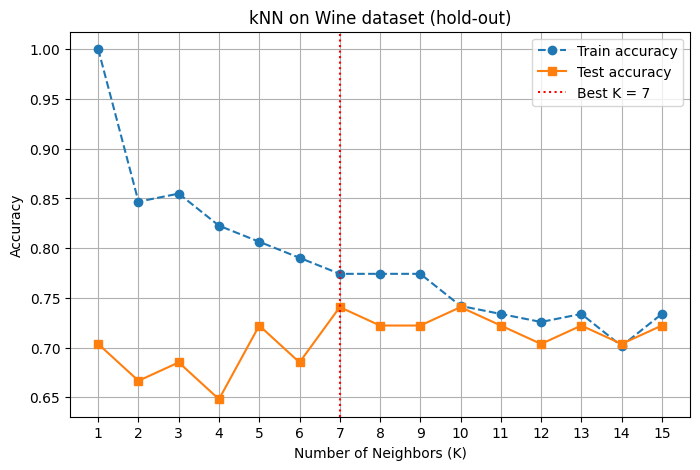

In [15]:
# #CHILLOUT: рисуем график
plt.figure(figsize=(8,5))
plt.plot(k_range, train_accuracies, label='Train accuracy', marker='o', linestyle='--')
plt.plot(k_range, test_accuracies, label='Test accuracy', marker='s', linestyle='-')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Accuracy')
plt.title('kNN on Wine dataset (hold-out)')
plt.legend()
plt.grid(True)
plt.xticks(k_range)
plt.axvline(x=best_k, color='red', linestyle=':', label=f'Best K = {best_k}')
plt.legend()
plt.show()

## #CHILLOUT — Анализ результата

Ты получил **K = 7** как оптимальное (по максимальной точности на test). Отлично, это очень типичное значение для Wine. Диапазон 3–9 — золотая середина, и 7 туда попадает.

### Что значит K = 7 для модели?

- Модель смотрит на **семь ближайших соседей** (вин) в обучающей выборке.
- Голосование: какой сорт встречается среди этих семи чаще — тот и предсказывается.
- Это достаточно, чтобы сгладить случайные выбросы (один-два странных вина не испортят прогноз), но при этом не слишком много, чтобы размыть границы между сортами.

---

## Что теперь по ТЗ?

Методичка требует:

1. ✅ Подобрать K (hold-out) — **сделано**.
2. ⏳ **Сравнить hold-out с кросс-валидацией** — следующий шаг.

Кросс-валидация (например, 5‑fold) даст более стабильную оценку того, какое K действительно лучше, и покажет, не переобучилась ли модель случайно из‑за конкретного разбиения (random_state=42).

---

## Task 3 (краткий план)

Мы сделаем:

- **5‑fold кросс-валидацию** на всём наборе Wine (или только на обучающей части? стандартно – на всём, но для чистоты сравнения можно и на train). В методике обычно так: подбираем K через кросс-валидацию на train, потом проверяем на test.
- Сравним лучшую accuracy, полученную через hold-out (K=7) и через CV (возможно, другое K даст такой же или лучший результат).
- Построим график средней точности на фолдах для разных K.
- Сделаем вывод: какой метод надёжнее, и почему.


>#DONE:
>- [x] Подобрать K (hold-out) — **сделано**.
___

# Task 3: <u>Сравнить</u> hold-out с <u>кросс-валидацией</u>

>#MAKEME:
> Сравнить hold-out с кросс-валидацией

## #CHILLOUT — Кросс-валидация на пальцах (с вином, учителями и экзаменами)

Ты уже знаешь **hold-out** (одно разбиение на train/test). Кросс-валидация — это его «старший брат», который решает проблему случайности. Давай без кода, только образы.

---

### 1. Проблема hold-out (почему его одного недостаточно)

Ты один раз взял колоду из 178 вин, случайно перемешал (random_state=42) и отложил 54 вина в test. Остальные 124 — train.  
Обучил kNN, подобрал K=7 по test.   

**Но что, если тебе просто повезло с разбиением?**  
Может быть, в test попали «лёгкие» вина, которые хорошо предсказываются. А в другой день при другом разбиении K=7 показало бы точность ниже.  
Hold-out — это как один экзамен. Но ученик может сдать его удачно случайно.

---

### 2. Идея кросс-валидации — «сдай экзамен 5 раз, по разным билетам»

Ты делишь все 178 вин **не на две, а на 5 равных частей** (фолдов). Например, по 35–36 вин в каждом фолде (примерно). Далее:

- **Раунд 1:** Фолд 1 — test, фолды 2+3+4+5 — train. Обучаешь kNN (например, с K=7) на этих 142 винах, проверяешь на фолде 1 (36 вин). Запоминаешь точность.
- **Раунд 2:** Фолд 2 — test, фолды 1+3+4+5 — train. Снова обучаешь и проверяешь на новом test.
- **Раунд 3, 4, 5:** аналогично.

В конце у тебя есть **5 оценок точности** (по каждой части). Ты их **усредняешь** — это и есть кросс-валидационная точность для K=7.

---

### 3. Почему это круче?

- Каждое вино побывало в test ровно один раз, а в train — 4 раза. Никто не обижен.
- Если в каком-то фолде попались «сложные» вина, это не сломает общую оценку, потому что остальные 4 фолда сгладят.
- Ты получаешь **более стабильную и честную** оценку того, как модель будет работать на новых данных.

---

### 4. А как подбирать K с кросс-валидацией?

Вместо одного графика (hold-out) ты делаешь так:

- Для каждого K (1..15) выполняешь полную 5‑fold кросс-валидацию и получаешь **среднюю точность по всем 5 фолдам**.
- Строишь график: по оси X — K, по оси Y — средняя CV‑точность.
- Выбираешь K, при котором эта средняя точность максимальна.

Этот K считается **более надёжным**, потому что он основан на многократных проверках, а не на одном случайном разбиении.

---

### 5. А как же test выборка? Она всё ещё нужна?

Да. После того как ты подобрал K через кросс-валидацию (используя только train или весь датасет — зависит от подхода), ты **обучаешь финальную модель** на всех train (или на всём датасете, кроме test), и **один единственный раз** проверяешь на отложенном test, который **вообще не участвовал в подборе**. Это даёт финальную, полностью независимую оценку.

В нашей лабораторной, вероятно, можно сделать так:  
- Весь Wine разбиваем на train (80%) и test (20%).  
- На train делаем кросс-валидацию (5‑fold внутри train) для подбора K.  
- Затем проверяем лучший K на test.

Но так как методичка просит **сравнить hold-out и кросс-валидацию** — мы можем и просто на всём датасете сделать кросс-валидацию и сравнить, какое K она выберет, против K=7, полученного ранее. Это будет допустимо для учебной работы.

---

### 6. Связь с твоим K=7

Вероятнее всего, кросс-валидация тоже выберет K=7 или 5, или 9 — что-то рядом. Если увидишь, что CV выбирает K=5, а hold-out дал K=7 — это нормально. Тогда ты напишешь в выводах:  
> «Hold-out чувствителен к разбиению, поэтому кросс-валидация предпочтительнее для выбора гиперпараметра».


## #DEEP [tech] — Что нам нужно в коде
>#CHILLOUT — Инструменты (I) для Task 3: кросс-валидация

### 1. Базовый «станок» — `cross_val_score` из `sklearn.model_selection`

**Что это:** Готовая функция, которая принимает модель (kNN), данные (X, y), количество фолдов (cv=5) и метрику (accuracy), а возвращает массив из 5 чисел — точность на каждом фолде.

**Зачем:** Не нужно писать цикл по фолдам вручную, sklearn всё делает под капотом: перемешивает, разбивает, обучает, предсказывает, считает метрику.

**Как выглядит в коде:**
```python
from sklearn.model_selection import cross_val_score
scores = cross_val_score(knn, X, y, cv=5, scoring='accuracy')
```

---

### 2. Модель — `KNeighborsClassifier` (уже знакомая)

**Что это:** Классификатор kNN, у которого мы будем менять параметр `n_neighbors` (K).

**Зачем:** Один и тот же инструмент, но теперь его будем «прогонять» через кросс-валидацию вместо простого `fit`/`predict` на train/test.

---

### 3. Данные — `X`, `y` (весь датасет Wine)

**Важный нюанс:** Для кросс-валидации мы используем **весь набор данных** (все 178 вин, все 13 признаков).  
Hold-out разделял данные один раз; кросс-валидация сделает это многократно внутри себя. **Отложенная test выборка не нужна** для подбора K (она нужна только для финальной независимой проверки, но методичка просит сравнить hold-out и CV как методы оценки — значит, можно сравнить точность на всём датасете для двух подходов).

---

### 4. Метрика — `scoring='accuracy'`

**Что это:** Строка, которая говорит `cross_val_score`, какую меру качества считать. Accuracy — доля правильных ответов.

**Зачем:** Для классификации accuracy — стандарт. В методичке, скорее всего, она и подразумевается.

---

### 5. Диапазон K — тот же `range(1, 16)`

**Что это:** Перебор K от 1 до 15, для каждого из которых мы будем запускать кросс-валидацию.

**Зачем:** Чтобы найти K, дающее максимальную среднюю точность по фолдам.

---

### 6. Дополнительный, но важный инструмент — `np.mean()`

**Что это:** Функция NumPy для вычисления среднего арифметического массива.

**Зачем:** `cross_val_score` возвращает 5 чисел. Нам нужно их усреднить, чтобы получить одну оценку для данного K.

---

### 7. График — `matplotlib.pyplot` (уже использовали)

**Что это:** Библиотека для построения графиков.

**Зачем:** Нарисовать два графика на одной картинке:
- hold-out accuracy (из Task 2)
- cross-validation accuracy (средняя по фолдам)  
Чтобы визуально сравнить, как они ведут себя с ростом K.

---

## #NOTE: Важное различие в подходах

| Подход | Что делаем | Какая точность получается |
|--------|------------|---------------------------|
| **Hold-out** (Task 2) | Одно разбиение → обучение на train, проверка на test | Одно число accuracy (например, 0.944 для K=7) |
| **Cross-validation** (Task 3) | 5 разбиений → 5 обучений и проверок → усредняем | 5 чисел, затем среднее (например, 0.938 для K=7) |

**Сравнивать** можно:
- Лучшую accuracy по hold-out (при оптимальном K) vs лучшую accuracy по CV (при оптимальном K)
- Или смотреть на форму кривых на графике.

---

## Что нужно сделать прямо сейчас (перед кодом)

Убедись, что у тебя в среде (ноутбуке/скрипте) уже импортированы:
```python
from sklearn.model_selection import cross_val_score
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
```
А также загружены `X`, `y` (весь датасет Wine) — это мы сделали в Task 1.

In [19]:
from sklearn.model_selection import cross_val_score
#Кросс-валидация на 5 фолдах cv=5
scores = cross_val_score(knn, X, y, cv=5, scoring='accuracy')

In [ ]:
# Task 3: Сравнение hold-out и кросс-валидации для подбора K на Wine
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsClassifier

>NOTE: Т.е. на каждом фолде нашей выборки у нас вычисляется
>$CV_k = \frac{1}{k} \sum_{i=1}^k E_i$, 

где $E_i$ — это:
$\text{Accuracy} = \frac{1}{n} \sum_{i=1}^{n} \mathbf{1}[\hat{y}_i = y_i]$

>CUTTING: Проще говоря, алгоритм:
1) разбиваем нашу выборку по k фолдам (у нас k=5)

2.1) в каждом фолде считаем свою accuracy: доля правильно предсказанных ко всем $n$ предсказаниям модели:
на каждом шаге смотрит — если текущ. предсказание из фолда $\hat{y}_i$ совпало с правильным (target) $y_i$, то +1 в сумму верных ответов, иначе — +0

2.2) для каждого фолда вычисляем среднее значение accuracy из предыдущего п. 2), где среднее считается относительно того номера фолда $i$, которое мы уже проитерировали (т.е. если текущ. фолд второй, то считаем среднее поделив на 2, если третий - делим на 3 и т.д.)

*Доп.:
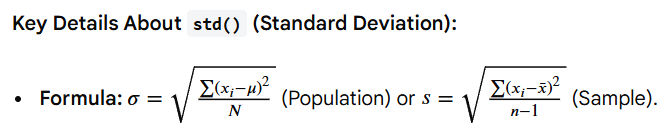

In [22]:
# # #CHILLOUT: Кросс-валидация (5‑fold, accuracy)
# cv_scores = []        # здесь будем хранить средние значения по фолдам для каждого k
# cv_std = []           # стандартное отклонение (для доверительных интервалов)
# for k in k_range:
#     knn = KNeighborsClassifier(n_neighbors=k)
#     # cross_val_score возвращает массив из 5 чисел (точность на каждом фолде по кросс-валидации)
#     scores = cross_val_score(knn, X, y, cv=5, scoring='accuracy') # возвр accuracy -> cross_val
#     cv_scores.append(scores.mean()) # добавляет среднее от cross_val (NOTE: cross_val среднее от accuracy, а потом берем еще ср - mean от cross_val)
#     cv_std.append(scores.std()) # std - стандартное отклонение
# # Находим лучшее K по hold-out и по CV

>[x] ARCHV